In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [77]:
df = pd.read_csv("Mall_Customers.csv")

In [78]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [79]:
df.sample(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
176,177,Male,58,88,15
33,34,Male,18,33,92
121,122,Female,38,67,40
180,181,Female,37,97,32
102,103,Male,67,62,59


In [80]:
df.shape

(200, 5)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [82]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [83]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [84]:
df = df.drop("CustomerID", axis=1)

In [85]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [86]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

In [88]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [89]:
X = df.values

In [90]:
X.shape

(200, 4)

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [92]:
X[:5]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992]])

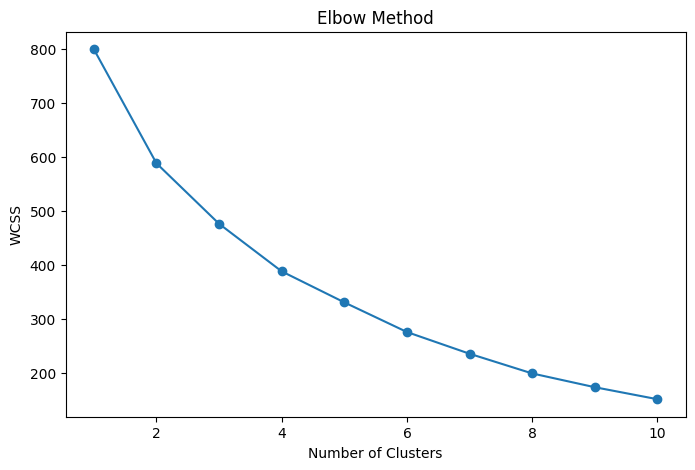

In [93]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [94]:
K = 5

In [95]:
np.random.seed(42)

random_idx = np.random.choice(X.shape[0], K, replace=False)

centroids = X[random_idx]

In [96]:
centroids

array([[ 1.12815215, -1.06573534, -0.02137488,  0.06987881],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [ 1.12815215,  1.51786549, -1.16645776, -1.7935561 ],
       [ 1.12815215, -0.34806844,  0.66567484, -1.91002079],
       [ 1.12815215,  1.4460988 ,  0.39848884, -1.52180518]])

In [97]:
print(centroids.shape)

(5, 4)


In [98]:
distances = np.linalg.norm(
    X[:, np.newaxis] - centroids,
    axis=2
)

In [99]:
print(distances.shape)

(200, 5)


In [100]:
distances[:5]

array([[1.82584143, 1.5792905 , 3.29119086, 3.01953344, 3.74047651],
       [2.06496245, 0.21817778, 4.13489133, 4.03712911, 4.40351821],
       [3.18598021, 3.48335501, 3.54834551, 3.27199529, 4.04191839],
       [2.79751795, 2.02309934, 4.40753672, 4.35741655, 4.65892264],
       [2.68731395, 2.60404695, 3.25413778, 3.43776965, 3.68947406]])

In [101]:
labels = np.argmin(distances, axis=1)

In [102]:
labels[:20]

array([1, 1, 0, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1])

In [103]:
new_centroids = np.array([
    X[labels == i].mean(axis=0)
    for i in range(K)
])

In [104]:
new_centroids

array([[-0.14773421, -0.51153702,  0.28313234,  0.48613221],
       [-0.04700634, -0.97602698, -1.36048569,  1.00321383],
       [ 0.02014557,  0.90784862, -1.1569154 , -1.11029664],
       [ 0.25225762, -0.20141477,  1.19174915, -1.33107316],
       [ 0.1911487 ,  1.30089642,  0.06739123, -0.34903292]])

In [105]:
np.allclose(centroids, new_centroids)

False

In [106]:
for i in range(100):

    distances = np.linalg.norm(
        X[:, np.newaxis] - centroids,
        axis=2
    )

    labels = np.argmin(
        distances,
        axis=1
    )

    new_centroids = np.array([
        X[labels == j].mean(axis=0)
        for j in range(K)
    ])

    if np.allclose(
        centroids,
        new_centroids
    ):
        print(f"Converged at iteration {i}")
        break

    centroids = new_centroids

Converged at iteration 11


In [107]:
plot_df = pd.DataFrame(X, columns=df.columns)

plot_df["Cluster"] = labels

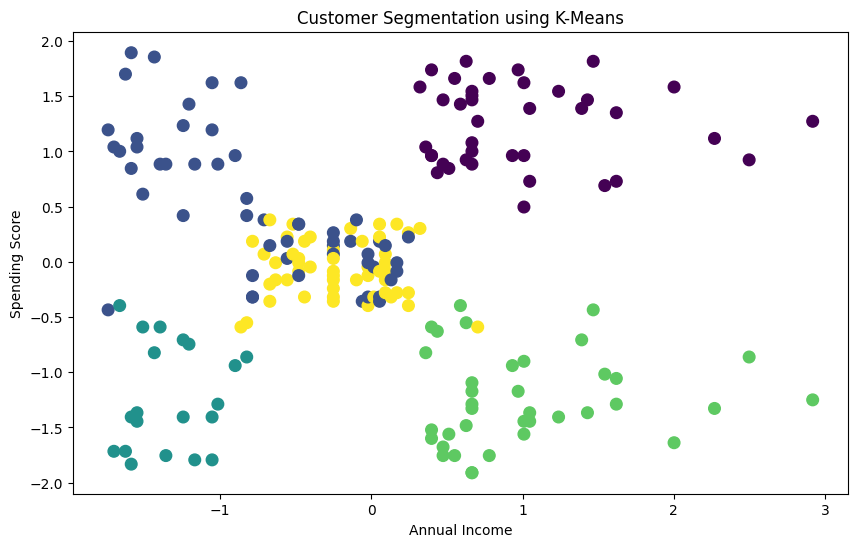

In [108]:
plt.figure(figsize=(10,6))

plt.scatter(
    plot_df["Annual Income (k$)"],
    plot_df["Spending Score (1-100)"],
    c=plot_df["Cluster"],
    cmap="viridis",
    s=70
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.show()

In [109]:
centroids_original = scaler.inverse_transform(centroids)

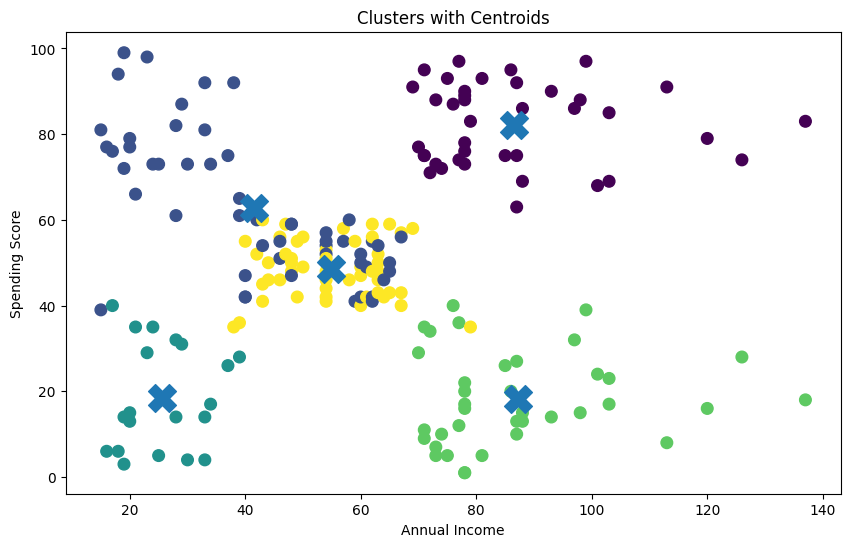

In [110]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=labels,
    cmap="viridis",
    s=70
)

plt.scatter(
    centroids_original[:,2],
    centroids_original[:,3],
    marker='X',
    s=400
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters with Centroids")

plt.show()

In [111]:
import plotly.express as px

plot_df = df.copy()
plot_df["Cluster"] = labels.astype(str)

fig = px.scatter_3d(
    plot_df,
    x="Age",
    y="Annual Income (k$)",
    z="Spending Score (1-100)",
    color="Cluster",
    title="Interactive 3D Customer Segmentation",
    opacity=0.8
)

fig.update_layout(
    width=900,
    height=700
)

fig.show()

In [112]:
import plotly.graph_objects as go

fig = go.Figure()

# Customers
fig.add_trace(
    go.Scatter3d(
        x=df["Age"],
        y=df["Annual Income (k$)"],
        z=df["Spending Score (1-100)"],
        mode='markers',
        marker=dict(
            size=5,
            color=labels,
            colorscale='Viridis'
        ),
        name='Customers'
    )
)

# Centroids
fig.add_trace(
    go.Scatter3d(
        x=centroids_original[:,1],
        y=centroids_original[:,2],
        z=centroids_original[:,3],
        mode='markers',
        marker=dict(
            size=15,
            symbol='diamond'
        ),
        name='Centroids'
    )
)

fig.update_layout(
    title='3D K-Means Clustering with Centroids',
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Annual Income',
        zaxis_title='Spending Score'
    )
)

fig.show()